In [ ]:
# STEP 1: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# STEP 2: Load the Dataset
df = pd.read_csv("Titanic-Dataset.csv")

In [ ]:
# STEP 3: Understand the Data
print("First 5 Rows of Dataset:")
print(df.head())
print("\nColumn Names:")
print(df.columns)
print("\nDataset Information:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())

First 5 Rows of Dataset:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8

In [ ]:
# STEP 4: Format Columns Properly
df['Sex'] = df['Sex'].astype('category')
df['Embarked'] = df['Embarked'].astype('category')
# Verify updated datatypes
print("\nUpdated Data Types:")
print(df.dtypes)


Updated Data Types:
PassengerId       int64
Survived          int64
Pclass            int64
Name             object
Sex            category
Age             float64
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
Cabin            object
Embarked       category
dtype: object


In [ ]:
# Handle Missing Values
# Age column -> fill with median
df['Age'] = df['Age'].fillna(df['Age'].median())
# Embarked column -> fill with most frequent values
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
# Cabin column -> too many missing values, so drop it
df.drop(columns=['Cabin'], inplace=True)
# Verify missing values again
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


Missing Values After Cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


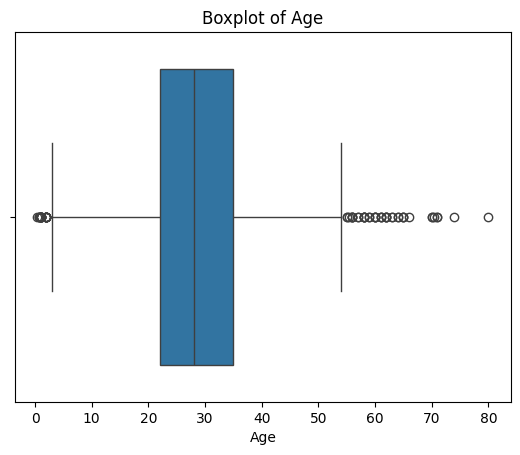

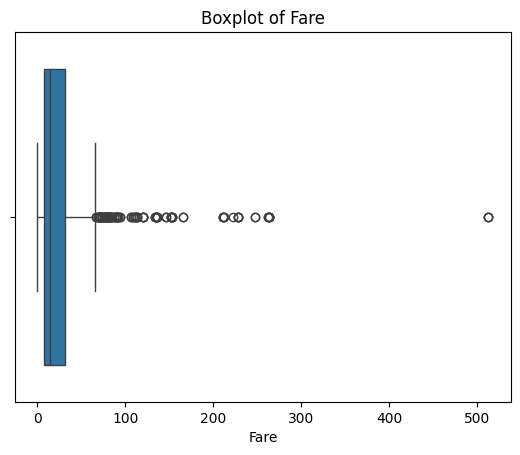

In [ ]:
# STEP 6: Identify Outliers
plt.figure()
sns.boxplot(x=df['Age'])
plt.title("Boxplot of Age")
plt.show()

plt.figure()
sns.boxplot(x=df['Fare'])
plt.title("Boxplot of Fare")
plt.show()

In [ ]:
# Remove Outliers using IQR Method
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
df = df[(df['Fare'] >= lower_limit) & (df['Fare'] <= upper_limit)]
print(df)

     PassengerId  Survived  Pclass  \
0              1         0       3   
2              3         1       3   
3              4         1       1   
4              5         0       3   
5              6         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                             Name     Sex   Age  SibSp  Parch  \
0                         Braund, Mr. Owen Harris    male  22.0      1      0   
2                          Heikkinen, Miss. Laina  female  26.0      0      0   
3    Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1      0   
4                        Allen, Mr. William Henry    male  35.0      0      0   
5                                Moran, Mr. James    male  28.0      0      0   
..                                            ...     ...

In [ ]:
# STEP 7: Convert Categorical Variables into Numerical
# Use one-hot encoding
df = pd.get_dummies(df, columns=['Sex','Embarked'], drop_first=True)

In [ ]:
# STEP 8: Correlation Analysis
# Drop non-numeric and identifier columns before correlation analysis
df_corr = df.drop(columns=['PassengerId', 'Name', 'Ticket'], errors='ignore')
correlation_matrix = df_corr.corr()
print("\nCorrelation Matrix:")
print(correlation_matrix)


Correlation Matrix:
            Survived    Pclass       Age     SibSp     Parch      Fare  \
Survived    1.000000 -0.219870 -0.124165 -0.003237  0.096196  0.180374   
Pclass     -0.219870  1.000000 -0.343962  0.127484  0.100833 -0.593969   
Age        -0.124165 -0.343962  1.000000 -0.346854 -0.214153  0.046588   
SibSp      -0.003237  0.127484 -0.346854  1.000000  0.417657  0.447603   
Parch       0.096196  0.100833 -0.214153  0.417657  1.000000  0.385990   
Fare        0.180374 -0.593969  0.046588  0.447603  0.385990  1.000000   
Sex_male   -0.502914 -0.012656  0.130120 -0.146633 -0.284502 -0.139901   
Embarked_Q  0.043638  0.211821 -0.020981 -0.014168 -0.069229 -0.151141   
Embarked_S -0.098182 -0.094204  0.054112  0.054146  0.044881  0.048533   

            Sex_male  Embarked_Q  Embarked_S  
Survived   -0.502914    0.043638   -0.098182  
Pclass     -0.012656    0.211821   -0.094204  
Age         0.130120   -0.020981    0.054112  
SibSp      -0.146633   -0.014168    0.054146  
Par

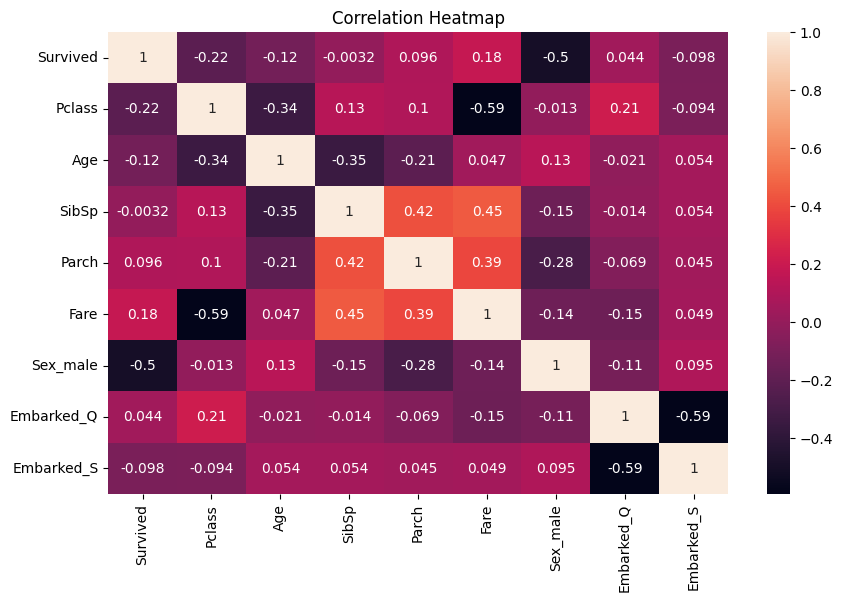

In [ ]:
#STEP 9:Heatmap Visualization
plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix, annot=True)
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
# STEP 10: Remove Highly Correlated Features
# If correlation between two variables is > 0.8
# they may cause multicollinearity
corr_matrix = df_corr.corr().abs()
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
high_corr_features = [
    column for column in upper_triangle.columns
    if any(upper_triangle[column] > 0.8)
]
print("\nHighly Correlated Columns:")
print(high_corr_features)
df.drop(columns=high_corr_features, inplace=True)


Highly Correlated Columns:
[]


In [ ]:
# STEP 11: Identify Input Attributes and Response Variable
# Response Variable (Target): Survived
# Input Attributes: Remaining columns except identifiers
y = df['Survived']
X = df.drop(columns=['Survived','PassengerId','Name','Ticket'])
print("\nInput Attributes:")
print(X.columns)
print("\nResponse Variable:")
print(y.name)


Input Attributes:
Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q',
       'Embarked_S'],
      dtype='object')

Response Variable:
Survived


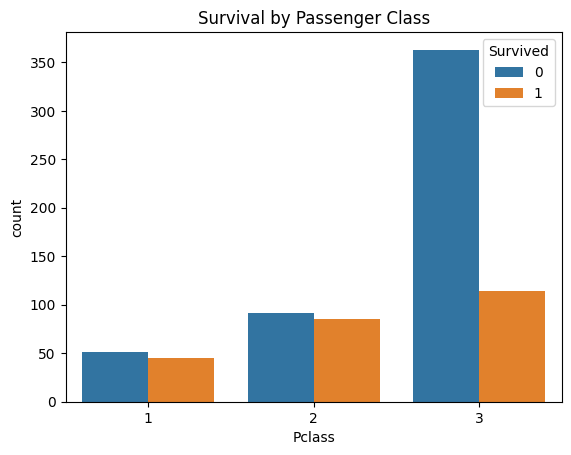

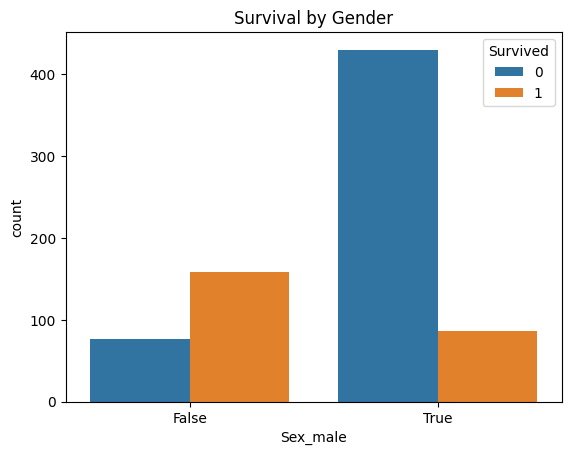

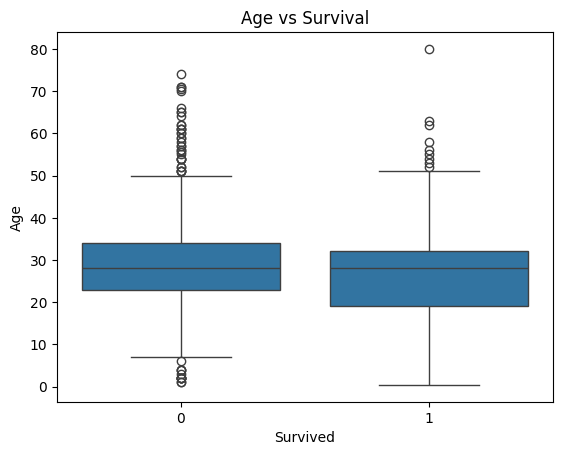

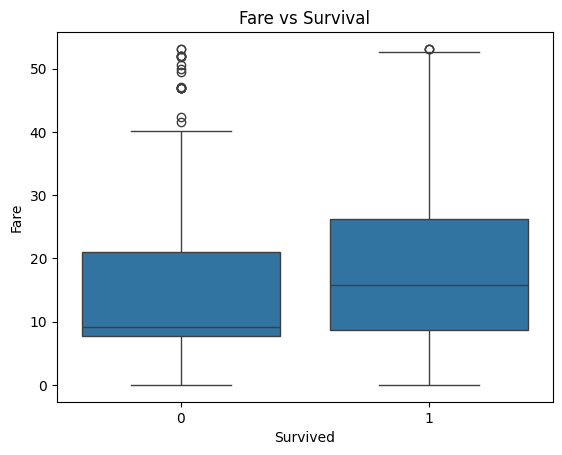

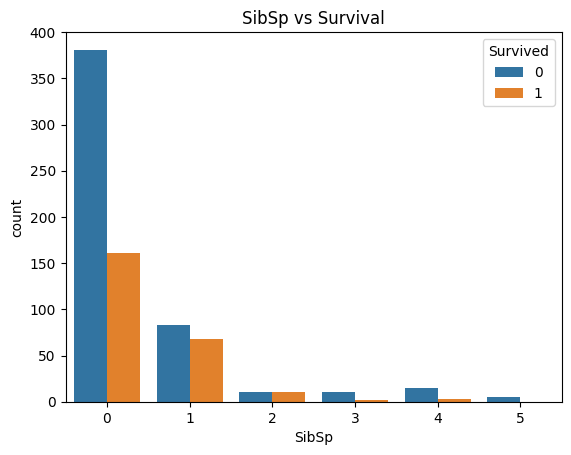

In [ ]:
# STEP 12: Visualization of Input Attributes vs Response Variable

# Survival by Passenger Class
plt.figure()
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Survival by Passenger Class")
plt.show()


# Survival by Gender
plt.figure()
sns.countplot(x='Sex_male', hue='Survived', data=df)
plt.title("Survival by Gender")
plt.show()


# Age vs Survival
plt.figure()
sns.boxplot(x='Survived', y='Age', data=df)
plt.title("Age vs Survival")
plt.show()


# Fare vs Survival
plt.figure()
sns.boxplot(x='Survived', y='Fare', data=df)
plt.title("Fare vs Survival")
plt.show()


# SibSp vs Survival
plt.figure()
sns.countplot(x='SibSp', hue='Survived', data=df)
plt.title("SibSp vs Survival")
plt.show()
